In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings("ignore")

In [6]:
# Data set Load
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Pixel value range: {X_train.min()} to {X_train.max()}")

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000,)
Pixel value range: 0 to 255


In [ ]:
# 2. PREPROCESSING THE DATA
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn  = X_test.reshape(-1, 28, 28, 1).astype('float32')

X_train_cnn = X_train_cnn / 255.0
X_test_cnn  = X_test_cnn  / 255.0

y_train_encoded = to_categorical(y_train, 10)
y_test_encoded  = to_categorical(y_test,  10)

print(f"Reshaped training data: {X_train_cnn.shape}")
print(f"Reshaped test data:     {X_test_cnn.shape}")
print(f"Encoded labels shape:   {y_train_encoded.shape}")

Reshaped training data: (60000, 28, 28, 1)
Reshaped test data:     (10000, 28, 28, 1)
Encoded labels shape:   (60000, 10)


In [ ]:
# 3. BUILDING THE CNN MODEL
print("Building CNN model...")

model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

print("CNN model built successfully")

Building CNN model...
CNN model built successfully


In [ ]:
# 4. COMPILING THE MODEL
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Architecture:")
model.summary()

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5. TRAINING THE MODEL
print("Training the model...")

history = model.fit(
    X_train_cnn,
    y_train_encoded,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Training the model...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.9035 - loss: 0.3225 - val_accuracy: 0.9765 - val_loss: 0.0784
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9732 - loss: 0.0903 - val_accuracy: 0.9838 - val_loss: 0.0546
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9816 - loss: 0.0621 - val_accuracy: 0.9870 - val_loss: 0.0452
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9842 - loss: 0.0515 - val_accuracy: 0.9864 - val_loss: 0.0446
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9866 - loss: 0.0426 - val_accuracy: 0.9875 - val_loss: 0.0415
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9884 - loss: 0.0369 - val_accuracy: 0.9882 - val_loss: 0.0395
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9895 - loss: 0.0329 - val_accuracy: 0.9888 - val_loss: 0.0392
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.

In [11]:
# 6. EVALUATE ON TEST SET
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test_encoded, verbose=0)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")

Test Loss:     0.0256
Test Accuracy: 0.9919  (99.19%)


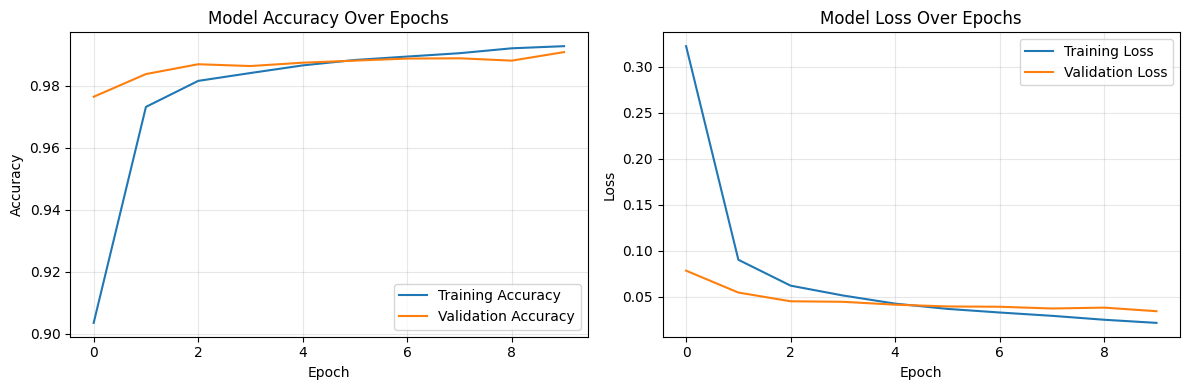

Plot saved as 'training_history.png'


In [12]:
# 7. VISUALIZE TRAINING HISTORY
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy curves
axes[0].plot(history.history['accuracy'],     label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curves
axes[1].plot(history.history['loss'],     label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100)
plt.show()
print("Plot saved as 'training_history.png'")

In [13]:
# 8. MAKE PREDICTIONS ON FIRST 10 TEST IMAGES
predictions      = model.predict(X_test_cnn[:10])
predicted_labels = np.argmax(predictions, axis=1)  # index of highest probability
actual_labels    = y_test[:10]

print("Predictions vs Actual Labels:")
print(f"Predicted: {predicted_labels}")
print(f"Actual:    {actual_labels}")
print(f"Match:     {predicted_labels == actual_labels}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
Predictions vs Actual Labels:
Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]
Match:     [ True  True  True  True  True  True  True  True  True  True]


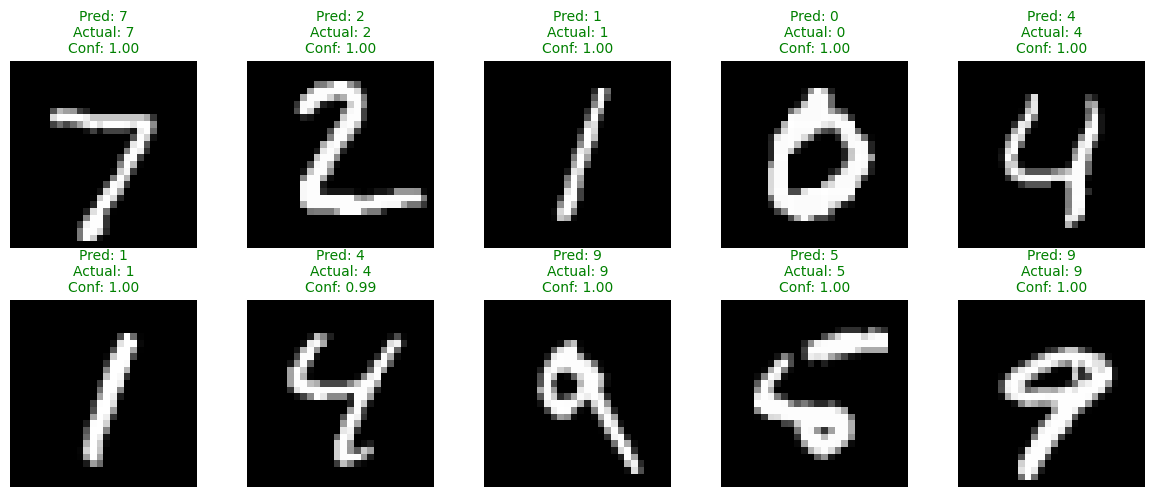

Prediction grid saved as 'predictions.png'


In [ ]:
# 9. VISUALIZE PREDICTIONS
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    digit_image = X_test[i].reshape(28, 28)
    axes[i].imshow(digit_image, cmap='gray')

    predicted  = predicted_labels[i]
    actual     = actual_labels[i]
    confidence = predictions[i][predicted]

    title = f"Pred: {predicted}\nActual: {actual}\nConf: {confidence:.2f}"
    color = 'green' if predicted == actual else 'red'
    axes[i].set_title(title, color=color, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=100)
plt.show()
print("Prediction grid saved as 'predictions.png'")

In [15]:
# 10. SAVE THE MODEL
model.save('mnist_cnn_model.h5')
print("Model saved as 'mnist_cnn_model.h5'")

Model saved as 'mnist_cnn_model.h5'


In [16]:
# 11. LOAD SAVED MODEL AND VERIFY
loaded_model = keras.models.load_model('mnist_cnn_model.h5')

test_pred = loaded_model.predict(X_test_cnn[0:1], verbose=0)
print(f"Loaded model prediction for first test image: {np.argmax(test_pred)}")
print(f"Actual label:                                 {y_test[0]}")

print("\n" + "="*50)
print("  CNN TRAINING COMPLETE!")
print("="*50)

Loaded model prediction for first test image: 7
Actual label:                                 7

  CNN TRAINING COMPLETE!
